# Baby Food Topics — OpenAlex Explorer

Queries OpenAlex to get a feel for the research landscape before doing a full import.
Uses `meta.count` and `group_by` so it's fast — no paper content is downloaded.

**Sections:**
1. Paper counts per topic
2. Publication year distribution
3. Top 5 most-cited papers per topic
4. Study type breakdown

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from import_openalex import PREDEFINED_TOPICS, reconstruct_abstract

OPENALEX_BASE = 'https://api.openalex.org'
EMAIL = os.environ.get('OPENALEX_EMAIL', 'research@example.com')
HEADERS = {'User-Agent': f'mapo-baby-food-explore/1.0 (mailto:{EMAIL})'}
BASE_FILTERS = 'type:article,has_abstract:true'

print(f'Topics to explore: {len(PREDEFINED_TOPICS)}')
for k, v in PREDEFINED_TOPICS.items():
    print(f'  {k:30s} → "{v["query"][:60]}"')

Topics to explore: 100
  peanut_allergy                 → "peanut allergy infant introduction early prevention sensitis"
  egg_allergy                    → "egg allergy infant introduction prevention sensitisation"
  cow_milk_allergy               → "cow milk protein allergy infant formula sensitisation"
  tree_nut_allergy               → "tree nut allergy children walnut cashew almond introduction"
  wheat_gluten_allergy           → "wheat gluten allergy infant introduction sensitisation celia"
  soy_allergy                    → "soy allergy infant soy protein formula sensitisation"
  sesame_allergy                 → "sesame allergy infant children sensitisation introduction"
  fish_shellfish_allergy         → "fish shellfish allergy infant children introduction preventi"
  multiple_food_allergy          → "multiple food allergy infant polysensitisation management di"
  oral_immunotherapy_allergy     → "oral immunotherapy food allergy desensitisation children pea"
  early_allergen_int

## 1. Paper counts per topic

Fetches just `meta.count` from OpenAlex — one request per topic, no paper content downloaded.

In [2]:
def get_count(query, extra_filter=None):
    """Return total OpenAlex result count for this query, with no paper data fetched."""
    f = BASE_FILTERS
    if extra_filter:
        f += ',' + extra_filter
    params = {'search': query, 'filter': f, 'per-page': 1, 'select': 'id'}
    r = requests.get(f'{OPENALEX_BASE}/works', params=params, headers=HEADERS, timeout=20)
    r.raise_for_status()
    return r.json().get('meta', {}).get('count', 0)

rows = []
for key, cfg in PREDEFINED_TOPICS.items():
    total = get_count(cfg['query'])
    cited = get_count(cfg['query'], extra_filter='cited_by_count:>10')
    highly_cited = get_count(cfg['query'], extra_filter='cited_by_count:>100')
    rows.append({
        'topic': key,
        'name': cfg['name'],
        'total_papers': total,
        'cited_10plus': cited,
        'cited_100plus': highly_cited,
    })
    print(f'  {cfg["name"]:30s}  {total:6,d} total  {cited:5,d} cited>10  {highly_cited:4,d} cited>100')
    time.sleep(0.15)  # polite rate-limiting

counts_df = pd.DataFrame(rows).set_index('topic')
counts_df

  Peanut Allergy                     209 total     79 cited>10    15 cited>100
  Egg Allergy                        281 total    104 cited>10    27 cited>100
  Cow Milk Allergy                   188 total     78 cited>10    17 cited>100
  Tree Nut Allergy                    98 total     26 cited>10     3 cited>100
  Wheat & Gluten Allergy              22 total      7 cited>10     1 cited>100
  Soy Allergy                        163 total     65 cited>10    14 cited>100
  Sesame Allergy                     102 total     32 cited>10     6 cited>100
  Fish & Shellfish Allergy           321 total     89 cited>10    14 cited>100
  Multiple Food Allergies              8 total      2 cited>10     1 cited>100
  Oral Immunotherapy for Food Allergy     115 total     27 cited>10     9 cited>100
  Early Allergen Introduction         36 total     11 cited>10     1 cited>100
  Dietary Allergy Prevention       1,784 total    488 cited>10    82 cited>100
  Eczema & Food Allergy              323 total 

,name,total_papers,cited_10plus,cited_100plus
topic,,,,
peanut_allergy,Peanut Allergy,209,79,15
egg_allergy,Egg Allergy,281,104,27
cow_milk_allergy,Cow Milk Allergy,188,78,17
tree_nut_allergy,Tree Nut Allergy,98,26,3
wheat_gluten_allergy,Wheat & Gluten Allergy,22,7,1
...,...,...,...,...
baby_food_marketing,Baby Food Marketing & Industry,520,147,8
baby_food_labelling,Baby Food Labelling & Regulation,316,88,6
socioeconomic_infant_diet,Socioeconomic Factors in Infant Diet,2949,877,106


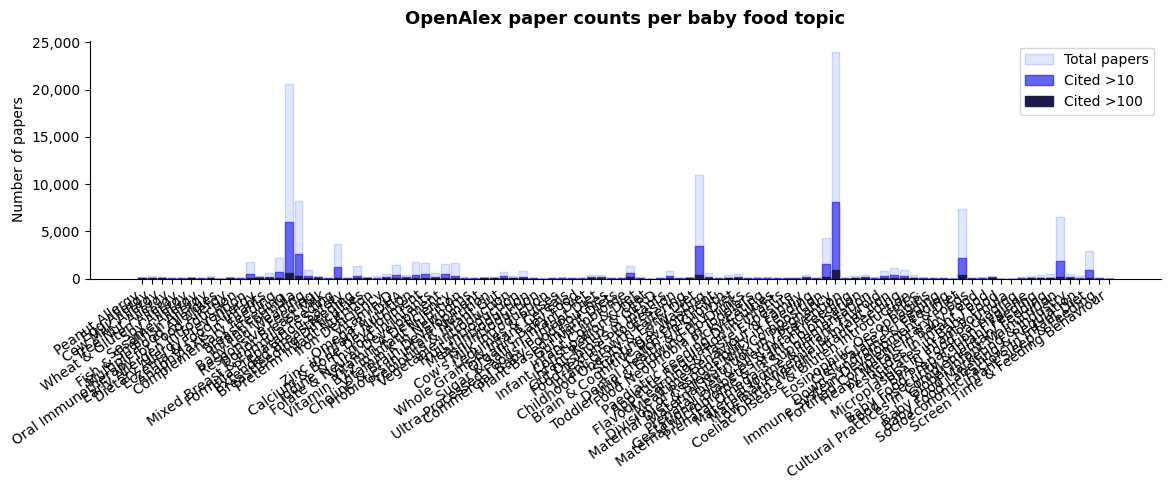

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
names = counts_df['name']
x = range(len(names))

ax.bar(x, counts_df['total_papers'], color='#e0e7ff', label='Total papers', edgecolor='#c7d2fe')
ax.bar(x, counts_df['cited_10plus'], color='#6366f1', label='Cited >10', edgecolor='#4f46e5')
ax.bar(x, counts_df['cited_100plus'], color='#1e1b4b', label='Cited >100', edgecolor='#1e1b4b')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_ylabel('Number of papers')
ax.set_title('OpenAlex paper counts per baby food topic', fontsize=13, fontweight='bold', pad=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Publication year distribution

Uses OpenAlex `group_by=publication_year` — returns a histogram with one API call per topic.

In [4]:
def get_year_distribution(query):
    """Return {year: count} dict using OpenAlex group_by — no paper content downloaded."""
    params = {
        'search': query,
        'filter': BASE_FILTERS,
        'group_by': 'publication_year',
        'per-page': 200,
    }
    r = requests.get(f'{OPENALEX_BASE}/works', params=params, headers=HEADERS, timeout=20)
    r.raise_for_status()
    groups = r.json().get('group_by', [])
    return {int(g['key']): g['count'] for g in groups if g['key'].isdigit()}

year_data = {}
for key, cfg in PREDEFINED_TOPICS.items():
    year_data[key] = get_year_distribution(cfg['query'])
    print(f'  {cfg["name"]:30s}  {len(year_data[key])} distinct years')
    time.sleep(0.15)

  Peanut Allergy                  27 distinct years
  Egg Allergy                     33 distinct years
  Cow Milk Allergy                41 distinct years
  Tree Nut Allergy                17 distinct years
  Wheat & Gluten Allergy          13 distinct years
  Soy Allergy                     35 distinct years
  Sesame Allergy                  21 distinct years
  Fish & Shellfish Allergy        28 distinct years
  Multiple Food Allergies         4 distinct years
  Oral Immunotherapy for Food Allergy  17 distinct years
  Early Allergen Introduction     9 distinct years
  Dietary Allergy Prevention      34 distinct years
  Eczema & Food Allergy           28 distinct years
  Anaphylaxis in Infants          31 distinct years
  Complementary Feeding           51 distinct years
  Breastfeeding                   62 distinct years
  Infant Formula                  51 distinct years
  Baby-Led Weaning                59 distinct years
  Responsive Feeding              25 distinct years
  Donor B

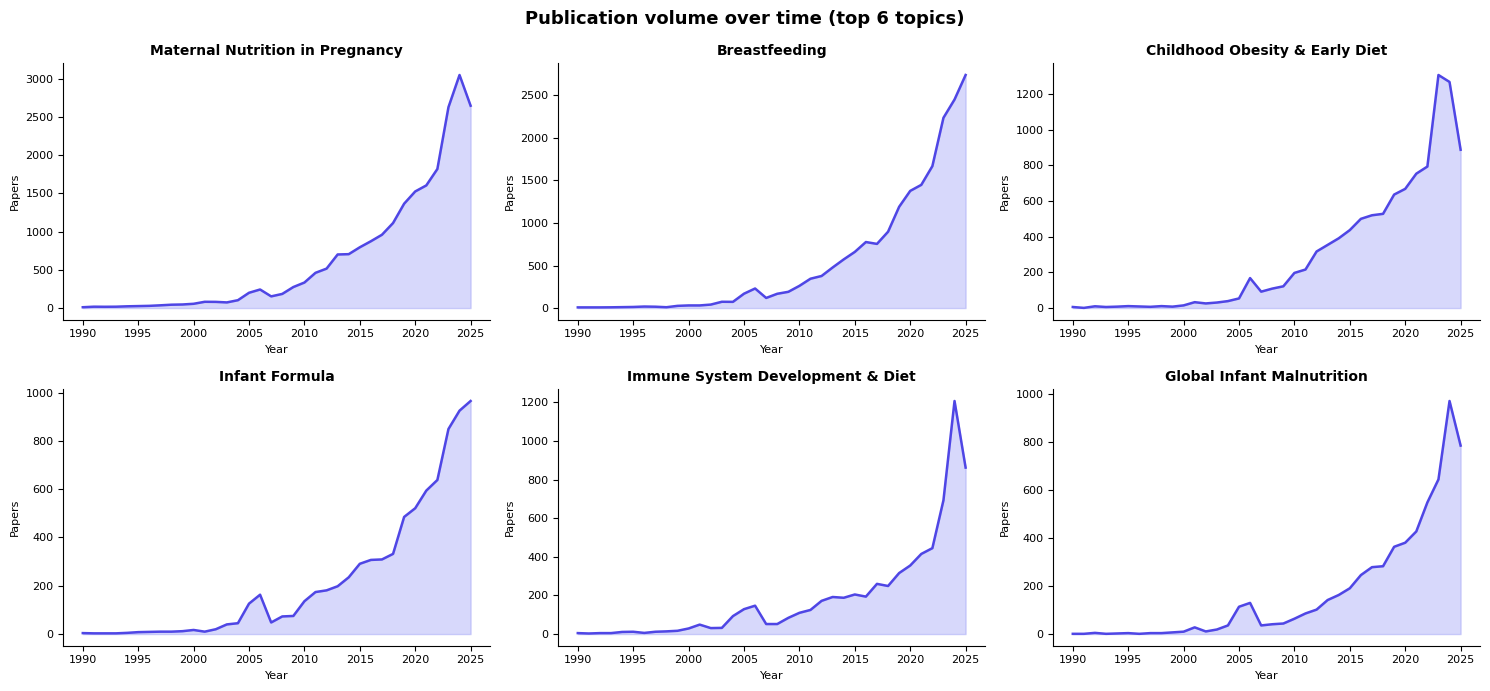

In [5]:
# Show year trends for the topics with the most papers
top_topics = counts_df['total_papers'].nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=False)
axes = axes.flatten()

for i, key in enumerate(top_topics):
    ax = axes[i]
    yd = year_data[key]
    years = sorted(y for y in yd if 1990 <= y <= 2025)
    counts = [yd[y] for y in years]
    ax.fill_between(years, counts, color='#6366f1', alpha=0.25)
    ax.plot(years, counts, color='#4f46e5', linewidth=1.8)
    ax.set_title(PREDEFINED_TOPICS[key]['name'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Papers', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

fig.suptitle('Publication volume over time (top 6 topics)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Top 5 most-cited papers per topic

Fetches just 5 papers per topic, sorted by citations descending.

In [6]:
def get_top_papers(query, n=5):
    params = {
        'search': query,
        'filter': BASE_FILTERS,
        'per-page': n,
        'sort': 'cited_by_count:desc',
        'select': 'id,title,publication_year,cited_by_count,authorships',
    }
    r = requests.get(f'{OPENALEX_BASE}/works', params=params, headers=HEADERS, timeout=20)
    r.raise_for_status()
    results = r.json().get('results', [])
    papers = []
    for w in results:
        authors = w.get('authorships', [])
        first = authors[0]['author']['display_name'] if authors else 'Unknown'
        papers.append({
            'year': w.get('publication_year'),
            'citations': w.get('cited_by_count', 0),
            'first_author': first,
            'title': (w.get('title') or '')[:90] + ('…' if len(w.get('title') or '') > 90 else ''),
        })
    return papers

top_papers = {}
for key, cfg in PREDEFINED_TOPICS.items():
    top_papers[key] = get_top_papers(cfg['query'])
    print(f'  {cfg["name"]:30s}  fetched top {len(top_papers[key])} papers')
    time.sleep(0.15)

  Peanut Allergy                  fetched top 5 papers
  Egg Allergy                     fetched top 5 papers
  Cow Milk Allergy                fetched top 5 papers
  Tree Nut Allergy                fetched top 5 papers
  Wheat & Gluten Allergy          fetched top 5 papers
  Soy Allergy                     fetched top 5 papers
  Sesame Allergy                  fetched top 5 papers
  Fish & Shellfish Allergy        fetched top 5 papers
  Multiple Food Allergies         fetched top 5 papers
  Oral Immunotherapy for Food Allergy  fetched top 5 papers
  Early Allergen Introduction     fetched top 5 papers
  Dietary Allergy Prevention      fetched top 5 papers
  Eczema & Food Allergy           fetched top 5 papers
  Anaphylaxis in Infants          fetched top 5 papers
  Complementary Feeding           fetched top 5 papers
  Breastfeeding                   fetched top 5 papers
  Infant Formula                  fetched top 5 papers
  Baby-Led Weaning                fetched top 5 papers
  Res

In [7]:
# Print as a formatted table per topic
for key, cfg in PREDEFINED_TOPICS.items():
    papers = top_papers[key]
    if not papers:
        print(f'\n--- {cfg["name"]} ---  (no results)\n')
        continue
    print(f'\n--- {cfg["name"]} ---')
    df = pd.DataFrame(papers)[['year', 'citations', 'first_author', 'title']]
    df.index = range(1, len(df)+1)
    print(df.to_string())


--- Peanut Allergy ---
   year  citations                                              first_author                                                                                        title
1  2013        588                                         Susan L. Prescott                      A global survey of changing patterns of food allergy burden in children
2  2010        571  EFSA Panel on Genetically Modified Organisms (GMO Panel)  Scientific Opinion on the assessment of allergenicity of GM plants and microorganisms and …
3  2020        522                                      Ignacio J. Ansotegui  IgE allergy diagnostics and other relevant tests in allergy, a World Allergy Organization …
4  2010        424                                        Alessandro Fiocchi  World Allergy Organization (WAO) Diagnosis and Rationale for Action against Cow's Milk All…
5  2013        287                                             D. Garmhausen  Characterization of different courses of atopic 

## 4. Study type breakdown

Uses OpenAlex `group_by=type` to see how many are articles, reviews, etc.

In [8]:
def get_type_breakdown(query):
    params = {
        'search': query,
        'filter': 'has_abstract:true',  # no type filter here so we can see breakdown
        'group_by': 'type',
        'per-page': 50,
    }
    r = requests.get(f'{OPENALEX_BASE}/works', params=params, headers=HEADERS, timeout=20)
    r.raise_for_status()
    return {g['key']: g['count'] for g in r.json().get('group_by', [])}

type_rows = []
for key, cfg in PREDEFINED_TOPICS.items():
    breakdown = get_type_breakdown(cfg['query'])
    row = {'name': cfg['name']}
    row.update(breakdown)
    type_rows.append(row)
    time.sleep(0.15)

types_df = pd.DataFrame(type_rows).fillna(0).set_index('name')
types_df = types_df.astype(int)

# Keep the most common types
top_types = types_df.sum().nlargest(6).index.tolist()
types_df[top_types]

,https://openalex.org/types/article,https://openalex.org/types/review,https://openalex.org/types/dissertation,https://openalex.org/types/preprint,https://openalex.org/types/book-chapter,https://openalex.org/types/book
name,,,,,,
Peanut Allergy,209,119,50,20,4,2
Egg Allergy,281,145,87,15,11,7
Cow Milk Allergy,188,95,29,6,6,2
Tree Nut Allergy,98,47,24,11,4,2
Wheat & Gluten Allergy,22,25,10,2,2,0
...,...,...,...,...,...,...
Baby Food Marketing & Industry,520,78,123,7,13,21
Baby Food Labelling & Regulation,316,47,63,6,3,16
Socioeconomic Factors in Infant Diet,2949,456,698,225,91,141


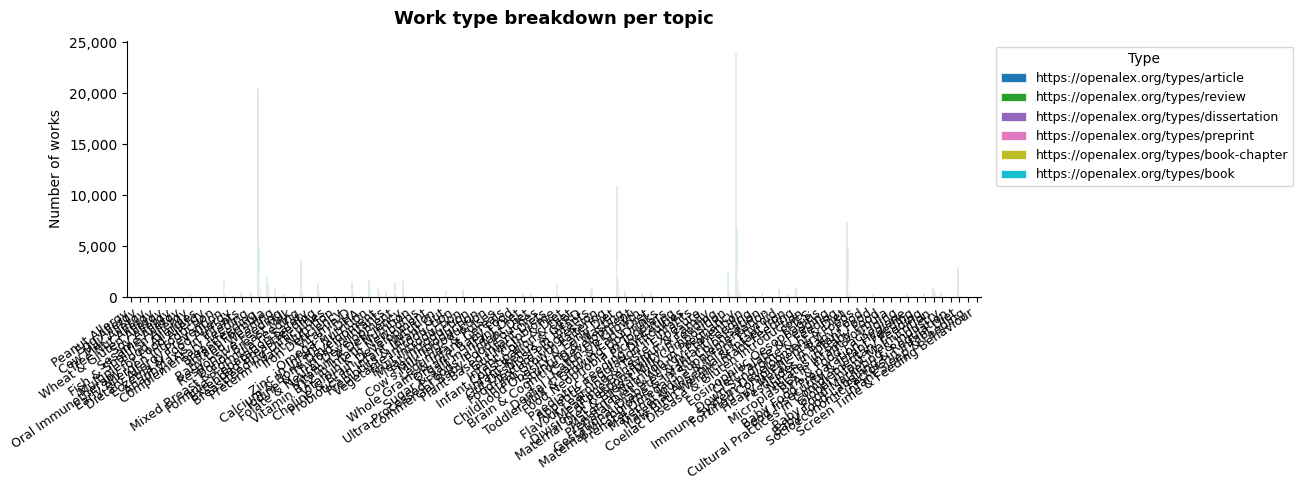

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_df = types_df[top_types]
plot_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', linewidth=0.5)

ax.set_xlabel('')
ax.set_ylabel('Number of works')
ax.set_title('Work type breakdown per topic', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(plot_df.index, rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Summary

Quick recap to inform how many papers to import per topic.

In [10]:
summary = counts_df[['name', 'total_papers', 'cited_10plus', 'cited_100plus']].copy()
summary['pct_cited_10plus'] = (summary['cited_10plus'] / summary['total_papers'] * 100).round(1)
summary['suggested_import'] = summary['cited_10plus'].clip(upper=500)
summary.columns = ['Name', 'Total', 'Cited >10', 'Cited >100', '% Cited >10', 'Suggested import']
print('\nImport recommendations (papers cited >10 times, capped at 500):\n')
print(summary.to_string())


Import recommendations (papers cited >10 times, capped at 500):

                                                                       Name  Total  Cited >10  Cited >100  % Cited >10  Suggested import
topic                                                                                                                                   
peanut_allergy                                               Peanut Allergy    209         79          15         37.8                79
egg_allergy                                                     Egg Allergy    281        104          27         37.0               104
cow_milk_allergy                                           Cow Milk Allergy    188         78          17         41.5                78
tree_nut_allergy                                           Tree Nut Allergy     98         26           3         26.5                26
wheat_gluten_allergy                                 Wheat & Gluten Allergy     22          7           1       